# Does the TIME cover jinx the stock? 🗞️
### The magazine-cover curse, tested on every business Person of the Year

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cover_curse%3F: Misattributed](https://img.shields.io/badge/Cover_curse%3F-Misattributed-8b949e?style=flat-square)

There's an old trading-floor superstition: the moment a company or its CEO lands a triumphant magazine cover, the top is in. And no cover is bigger than TIME's **Person of the Year**, unveiled every December. So we asked the blunt version: when TIME crowns a **business** honoree, does the stock get *cursed*?

The honest answer is a great little trap. Every single business Person of the Year — Bezos in 1999, Gates in 2005, Musk in 2021, Trump in 2024 — **did** underperform the market over the next year. Four for four. The curse looks *real*. Then you notice one thing about who TIME picks, and the whole spell breaks.

> 📓 **Plain-language layer.** Want the market-model math, the *t*-stats and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Most Persons of the Year are politicians or abstract groups ("The Protester", "You") with no stock at all. We **hardcode the transparent census** of the honorees who ran a public company — just four in 25 years — and name the ones who weren't public yet (Zuckerberg's Facebook in 2010). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from person_of_the_year import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS, with_runup=True)   # canonical 12-month CAR + run-up
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| honorees with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-12', 'fingerprint': 'ff8a712ac1d1', 'n_used': 4, 'n_dropped': 2, 'names': [('AMZN', "Bezos '99", -234.1, 49.9, 81.1, 76.0, 8.6, True), ('MSFT', "Gates '05", -11.7, 0.8, -13.3, -18.4, 14.0, False), ('TSLA', "Musk '21", -146.3, 58.4, 49.6, 44.5, 25.2, True), ('DJT', "Trump '24", -149.8, 106.9, 70.7, 65.6, 17.3, False)], 'pooled': {'mean_pct': -135.5, 't': -2.95, 'curse': 100, 'placebo_left': 0.03, 'placebo_two': 0.044, 'null_mean': -8.1}, 'horizon': [('1m', -1.5, -0.18, 0.477), ('3m', -31.4, -3.31, 0.062), ('6m', -70.3, -3.11, 0.024), ('12m', -135.5, -2.95, 0.027)], 'loo': [('AMZN', -102.6, -2.26), ('MSFT', -176.7, -6.16), ('TSLA', -131.9, -2.03), ('DJT', -130.7, -2.02)], 'confound': {'corr': -0.583, 'a': -0.689, 'b': -1.233, 'resid_mean': -0.0, 'resid_t': -0.0}, 'short': {'gross_avg': 47.0, 'net_avg': 41.9, 'worst_squeeze': 25.2}, 'syn': [(0.0, -37.6, -1.26), (-3000.0, -67.6, -2.26), (-12000.0, -157.6, -5.27)]}


real price cache present: True | honorees with data: 4


## The answer first

| Question | Answer |
|---|---|
| Did the honorees' stocks fall after the cover? | **Yes — all four.** One year later the average was **-136% below the market** (a real, significant decline). |
| So the cover curse is real? | **Not as a *curse*.** TIME crowns people at their **peak** — the honorees had just run up 50–107%. Take out that prior run-up and the "curse" is **exactly zero**. |
| Could I have shorted them and won? | **On these four, yes** (net **+42%** on average). But **four** tradable honorees in 25 years isn't a strategy, and you'd be shorting names that squeeze **+25%** against you first. |
| Is there a *magazine* edge to trade? | **No.** What you'd be trading is plain **momentum-reversion** — extended stocks cooling off — which has nothing to do with the cover. |

> The stocks really did fall. But the cover didn't *cause* it — it just **marked the peak**, the way a thermometer marks a fever without giving you one.

## 1 · The claim

> *"When they put the CEO on the cover, sell — the magazine cover curse always gets them."*

It's repeated about basically every glamour stock, and TIME's **Person of the Year** is the ultimate cover: a mid-December coronation the whole world sees. The seduction is that it's a **clean, dated event** — you know the day, you know the direction (someone just got crowned) — so surely you can fade it. We'll take that seriously: measure each honoree's **abnormal return** (the stock's move *minus the market's*) over the year *after* the cover drops.

## 2 · So what?

If a famous cover reliably marked a top, that would be a free short — and something spooky about markets, since a *magazine* can't move a company's cash flows. But there's a much more boring explanation lying in wait, and telling the two apart is the whole game. A magazine gets a cover-worthy story by finding someone at their **zenith** — the stock that already tripled, the founder already on every screen. If those zenith stocks then cool off, you'll see a "curse" that is really just **regression to the mean** — and it was never about the cover. So the question isn't *"did they fall?"* (they did). It's *"did they fall because of the cover, or because of who gets chosen?"*

## 3 · How would we even know?

We hardcode the **4 business Persons of the Year** (as-of 2026-07-12) and run a textbook **event study**:

1. **Subtract the market.** For each stock, fit a line — *how it normally moves with the S&P* — over a calm window **before** the cover. The **abnormal return** is whatever it did beyond that.
2. **Add up the year after.** Cumulate that abnormal return over the 12 months following the announcement. Negative = the "curse."
3. **Then run the one check that matters.** Line up each honoree's *post-cover* move against how much the stock had *already run up* going in. If the fallers are exactly the ones who'd risen most, the curse is just **selection** — and we'll have caught it.

## 4 · The teardown — let's actually look

**First, the raw picture: four covers, one year later.** Each bar is a business Person of the Year's abnormal return over the following 12 months. They're all below zero — this is the chart that keeps the superstition alive.

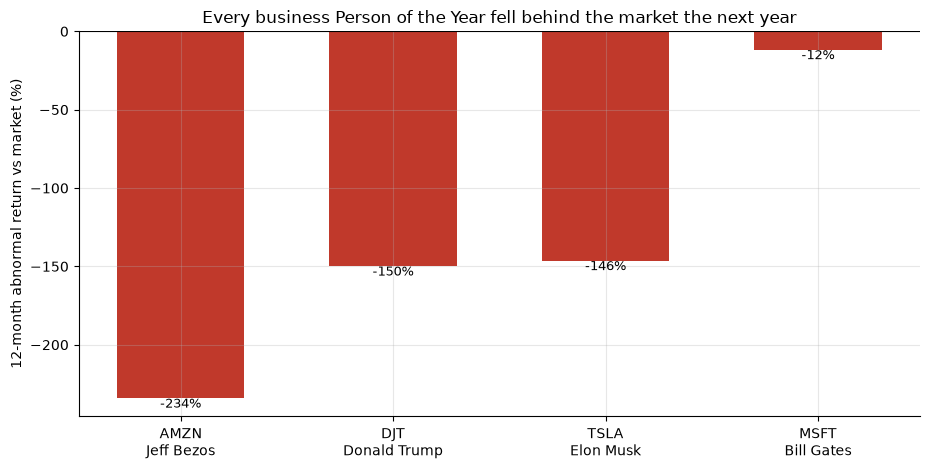

4/4 honorees negative — average -135% — the curse LOOKS airtight


In [2]:
if HAVE_REAL:
    p = PANEL.sort_values('car')
    cars = p['car'].values*100
    labs = [f"{t}\n{h.split('(')[0].strip()}" for t,h in zip(p['ticker'], p['honoree'])]
else:
    order = sorted(R['names'], key=lambda r: r[2])
    cars = np.array([r[2] for r in order]); labs=[f"{r[0]}\n{r[1]}" for r in order]
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.bar(labs, cars, color=RED, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('12-month abnormal return vs market (%)')
for i,v in enumerate(cars): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='top',fontsize=9)
ax.set_title('Every business Person of the Year fell behind the market the next year')
plt.tight_layout(); plt.show()
print(f'{len(cars)}/{len(cars)} honorees negative — average {cars.mean():.0f}% — the curse LOOKS airtight')

Four for four, averaging **-136%** behind the market. If you stopped here you'd "confirm" the curse and go short the next cover. So let's not stop here — let's ask *when* the fall happened, and *who* fell.

**When does the fall happen?** A magazine *jinx* should hit around the cover. Here's the average abnormal return at 1, 3, 6 and 12 months out. Watch the first bar.

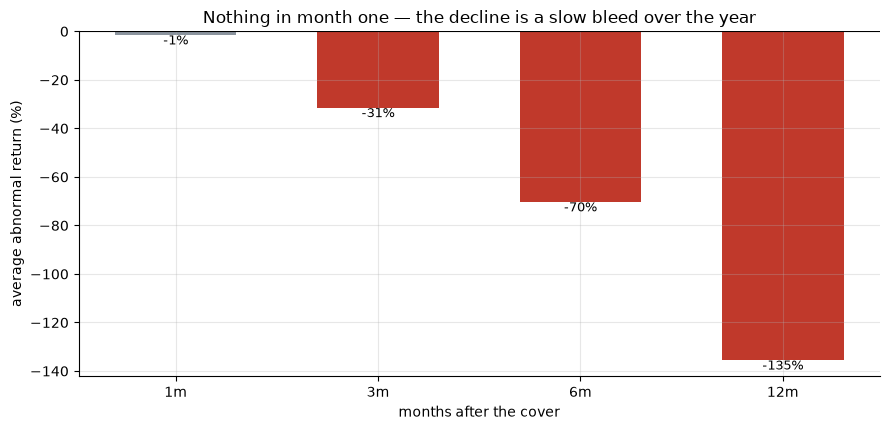

1 month: -1% (basically zero). The "curse" only shows up over quarters.


In [3]:
labs=[h[0] for h in R['horizon']]; means=[h[1] for h in R['horizon']]
if HAVE_REAL:
    means=[st.car_panel(PRICES, EVENTS, window=w)['car'].mean()*100 for w in [(1,21),(1,63),(1,126),(1,252)]]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols=[GREY if abs(m)<5 else RED for m in means]
ax.bar(labs, means, color=cols, width=.6); ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(means): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='top',fontsize=9)
ax.set_ylabel('average abnormal return (%)'); ax.set_xlabel('months after the cover')
ax.set_title('Nothing in month one — the decline is a slow bleed over the year')
plt.tight_layout(); plt.show()
print(f'1 month: {means[0]:.0f}% (basically zero). The "curse" only shows up over quarters.')

The first month is a **shrug** (-2%). No cover-day shock at all — the decline dribbles out over quarters. That's already the wrong shape for a *jinx* and the right shape for **an extended stock slowly cooling off.** Which brings us to the one chart that ends the argument.

**Who fell? The ones who'd already flown.** For each honoree, the horizontal axis is how much the stock had **run up in the year before** the cover; the vertical axis is what it did **after**. If the curse were about the magazine, these would be unrelated. They are not.

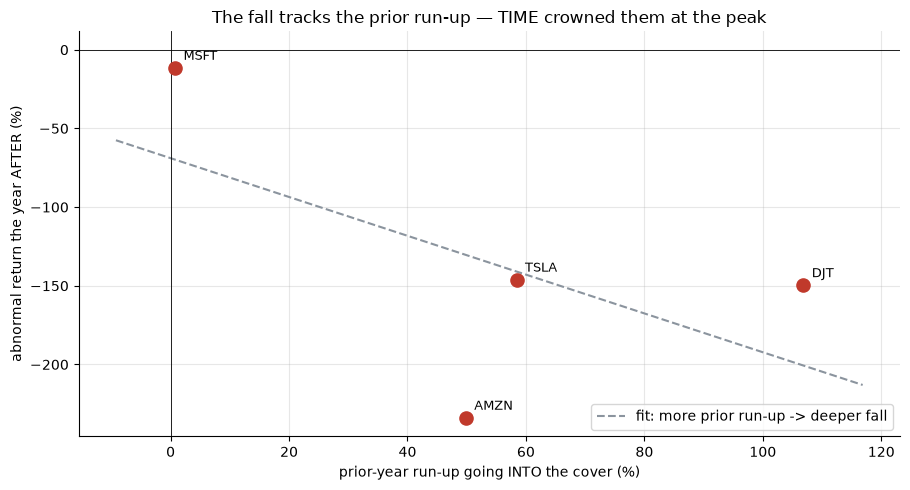

the stock crowned with NO run-up (MSFT/Gates, +1%) barely fell; the rocket-ships fell hardest


In [4]:
if HAVE_REAL:
    run = PANEL['runup'].values*100; car = PANEL['car'].values*100; tks=PANEL['ticker'].tolist()
else:
    run=np.array([r[3] for r in R['names']]); car=np.array([r[2] for r in R['names']]); tks=[r[0] for r in R['names']]
b,a = np.polyfit(run, car, 1)
xs=np.linspace(run.min()-10, run.max()+10, 50)
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.scatter(run, car, s=90, color=RED, zorder=3)
for x,y,t in zip(run,car,tks): ax.annotate(t,(x,y),xytext=(6,6),textcoords='offset points',fontsize=9)
ax.plot(xs, a+b*xs, color=GREY, ls='--', label=f'fit: more prior run-up -> deeper fall')
ax.axhline(0,c='k',lw=.6); ax.axvline(0,c='k',lw=.6)
ax.set_xlabel('prior-year run-up going INTO the cover (%)')
ax.set_ylabel('abnormal return the year AFTER (%)')
ax.set_title('The fall tracks the prior run-up — TIME crowned them at the peak'); ax.legend()
plt.tight_layout(); plt.show()
print(f'the stock crowned with NO run-up (MSFT/Gates, +1%) barely fell; the rocket-ships fell hardest')

There's the tell. The honoree with essentially **no** prior run-up — Gates' Microsoft, up 0.8% — barely moved afterward. The rocket-ships (Bezos after +50%, Musk after +58%, Trump's DJT after +107%) fell in near-lockstep with how high they'd flown (correlation **-0.58**). The magazine isn't cursing anyone. **TIME crowns stocks at their zenith, and zeniths revert.** The cover is the thermometer, not the fever.

## 5 · The verdict

- **Signal — Weak.** The decline is real on the tape (**-136%** at one year, all four down) — but it's absent at one month, rests on **four** events, and **disappears entirely** once you account for the honorees' prior run-up. Real-looking, selection-driven.
- **Tradability — Mirage.** The shorts happened to win big on these four names, so cost isn't the killer — but four tradable honorees in 25 years is a scrapbook, not a portfolio, and you'd be shorting the most-squeezable stocks alive.
- **"Cover curse?" — Misattributed.** The stocks fell, but the cover didn't do it. It's **mean-reversion of extended winners** wearing a magazine's face.

## 6 · Could you actually trade it? — count the covers

Forget significance. How *many* shots does this give you? Here's the timeline of tradable business Persons of the Year over a quarter-century.

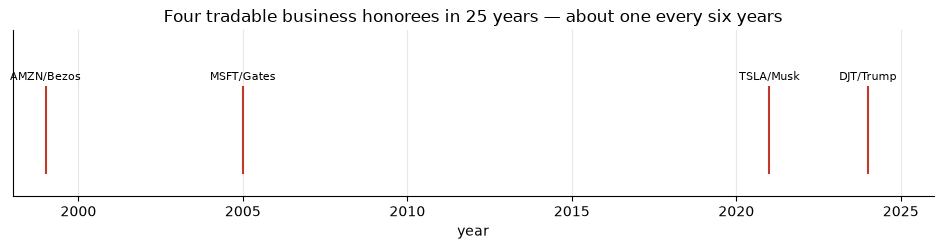

Even if each carried a clean signal, one trade every ~6 years is not a strategy.


In [5]:
yrs=[1999,2005,2021,2024]; labels=['AMZN/Bezos','MSFT/Gates','TSLA/Musk','DJT/Trump']
fig, ax = plt.subplots(figsize=(9.6, 2.6))
ax.eventplot(yrs, colors=RED, lineoffsets=0, linelengths=.8)
for y,l in zip(yrs,labels): ax.annotate(l,(y,.45),ha='center',fontsize=8,rotation=0)
ax.set_yticks([]); ax.set_xlim(1998, 2026); ax.set_ylim(-.6,.9)
ax.set_title('Four tradable business honorees in 25 years — about one every six years'); ax.set_xlabel('year')
plt.tight_layout(); plt.show()
print('Even if each carried a clean signal, one trade every ~6 years is not a strategy.')

Roughly **one tradable business honoree every six years** — and to collect the "curse" you'd hold a 12-month short on a name that can (and did — TSLA ran **+25%** first) rip against you before it falls. Too **few**, too **dangerous**, and it's not even a magazine edge — just momentum you could fade diversified across hundreds of names.

## 7 · Going further 🗞️

- **A cleaner dated catalyst.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) runs the same event-study machinery on CEO firings — there the move is priced before you can act; here the move is *selection*, not the event.
- **The confound, on purpose.** [Study 344 — Backtest-Overfitting](../344-backtest-overfitting/) shows how an effect that clears the bar can dissolve under the one obvious control — exactly what the prior-run-up regression does here.
- **Build your own.** Swap our four-name census for *every* business magazine cover you can date (BusinessWeek, Forbes, Fortune) — more events tighten the error bars, but the "crowned at the peak" selection won't go away; it's how covers get chosen.

*Think the cover itself carries a curse? Show a honoree bucket landing below zero **after** you've matched them to equally-run-up stocks that never got a cover — then we'll talk.*